### Business Analysis Notebook

Objective:

Analyze customer support performance to identify:
- Support workload trends
- Customer behavior patterns
- Product issues
- Operational bottlenecks
- Factors affecting customer satisfaction

Data source:
dbt-generated DuckDB models

Import libariaries

In [2]:
import duckdb
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

import warnings
warnings.filterwarnings("ignore")


sns.set_theme(
    style="whitegrid",
    context="notebook"
)

Connect to DuckDB

In [3]:
conn = duckdb.connect(
    "../customer_support.duckdb",
    read_only=True
)

print("Connected successfully")

Connected successfully


Query Helper

In [42]:
def run_query(query):
    return conn.execute(query).df()

Load Analytical Tables

In [43]:
fact_metrics = run_query("""
SELECT *
FROM main.fact_ticket_metrics
""")

dim_customers = run_query("""
SELECT *
FROM main.dim_customers
""")

dim_products = run_query("""
SELECT *
FROM main.dim_products
""")

fact_metrics.head()

,ticket_id,customer_id,product_id,ticket_type,ticket_status,ticket_priority,ticket_channel,purchase_date,first_response_time,time_to_resolution,customer_satisfaction_rating
0,1,bd76cedb7edb7edad02693111b3f9a12,f879ad7bfea7006aa52bba6f4b8d96d9,Technical issue,Pending Customer Response,Critical,Social media,2021-03-22,2023-06-01 12:15:36,NaT,NaN
1,2,48c46c02eff74a80d352e0154fd3a18b,62459136cefea3f345f166ae91b2b137,Technical issue,Pending Customer Response,Critical,Chat,2021-05-22,2023-06-01 16:45:38,NaT,NaN
2,3,36045d9133e6cbb83b69f86e55de8c38,4b01fecc9aaea14fd9d81c1639df377e,Technical issue,Closed,Low,Social media,2020-07-14,2023-06-01 11:14:38,2023-06-01 18:05:38,3.0
3,4,d0ad5318f2595dd7e537ba738a4b743c,2482944e6048d8f3b76417f0f5af9074,Billing inquiry,Closed,Low,Social media,2020-11-13,2023-06-01 07:29:40,2023-06-01 01:57:40,3.0
4,5,8f6418b4d3a5c97d9b32a75060b9aa3a,d59bcdb3e60ada2624c0becf9d391e7d,Billing inquiry,Closed,Low,Email,2020-02-04,2023-06-01 00:12:42,2023-06-01 19:53:42,1.0


KPI Summary

In [44]:
overview = run_query("""
SELECT

COUNT(*) AS total_tickets,

COUNT(DISTINCT customer_id)
AS unique_customers,

ROUND(
AVG(customer_satisfaction_rating),
2
)
AS avg_satisfaction

FROM main.fact_ticket_metrics

""")

overview

,total_tickets,unique_customers,avg_satisfaction
0,8791,8469,2.99


Ticket Volume Analysis

In [45]:
ticket_volume = run_query("""
SELECT

ticket_type,

COUNT(*) AS tickets

FROM main.fact_ticket_metrics

GROUP BY ticket_type

ORDER BY tickets DESC

""")

ticket_volume

,ticket_type,tickets
0,Refund request,1819
1,Technical issue,1811
2,Cancellation request,1762
3,Billing inquiry,1705
4,Product inquiry,1694


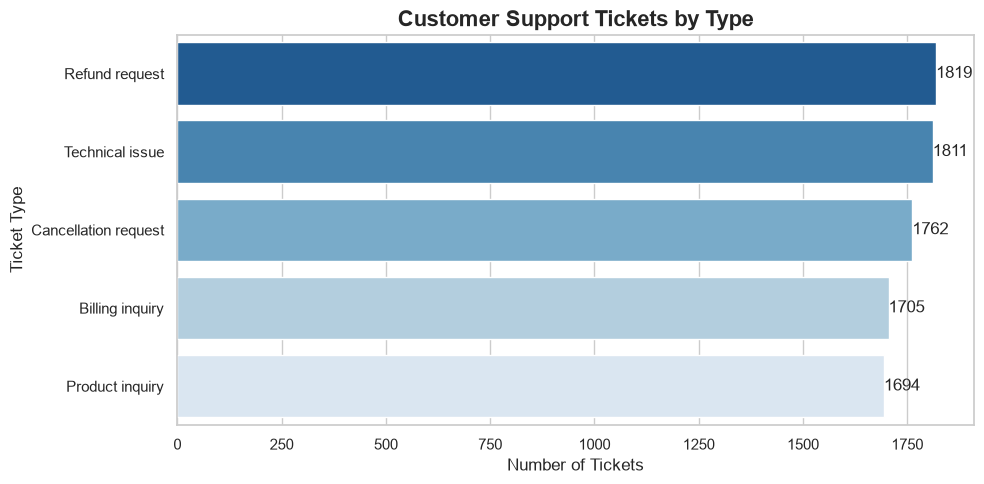

In [46]:
plt.figure(figsize=(10,5))

ax = sns.barplot(
    data=ticket_volume,
    x="tickets",
    y="ticket_type",
    palette="Blues_r"
)


plt.title(
    "Customer Support Tickets by Type",
    fontsize=16,
    weight="bold"
)

plt.xlabel("Number of Tickets")
plt.ylabel("Ticket Type")


for container in ax.containers:
    ax.bar_label(container)


plt.tight_layout()
plt.show()

Ticket Priority Analysis

In [47]:
priority = run_query("""
SELECT

ticket_priority,

COUNT(*) AS tickets

FROM main.fact_ticket_metrics

GROUP BY ticket_priority

ORDER BY tickets DESC

""")

priority

,ticket_priority,tickets
0,Medium,2272
1,Critical,2204
2,High,2178
3,Low,2137


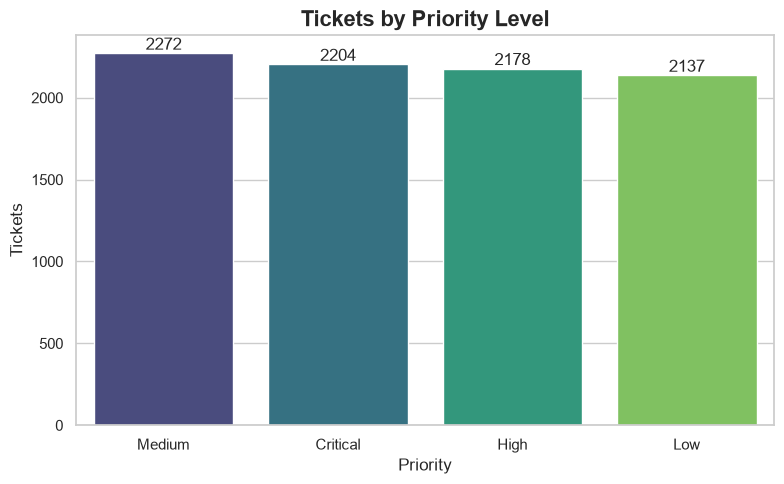

In [48]:
plt.figure(figsize=(8,5))


ax = sns.barplot(
    data=priority,
    x="ticket_priority",
    y="tickets",
    palette="viridis"
)


plt.title(
    "Tickets by Priority Level",
    fontsize=16,
    weight="bold"
)

plt.xlabel("Priority")
plt.ylabel("Tickets")


for container in ax.containers:
    ax.bar_label(container)


plt.tight_layout()

plt.show()

Product Issue Analysis

In [49]:
product_issues = run_query("""
SELECT

    p.product_name,

    COUNT(*) AS tickets

FROM main.fact_ticket_metrics f

LEFT JOIN main.dim_products p
ON f.product_id = p.product_id

GROUP BY p.product_name

ORDER BY tickets DESC

LIMIT 10

""")

product_issues

,product_name,tickets
0,Canon EOS,249
1,GoPro Hero,236
2,Nest Thermostat,232
3,Amazon Echo,230
4,LG Smart TV,229
5,Philips Hue Lights,229
6,Sony Xperia,228
7,Apple AirPods,227
8,Sony 4K HDR TV,226
9,Roomba Robot Vacuum,224


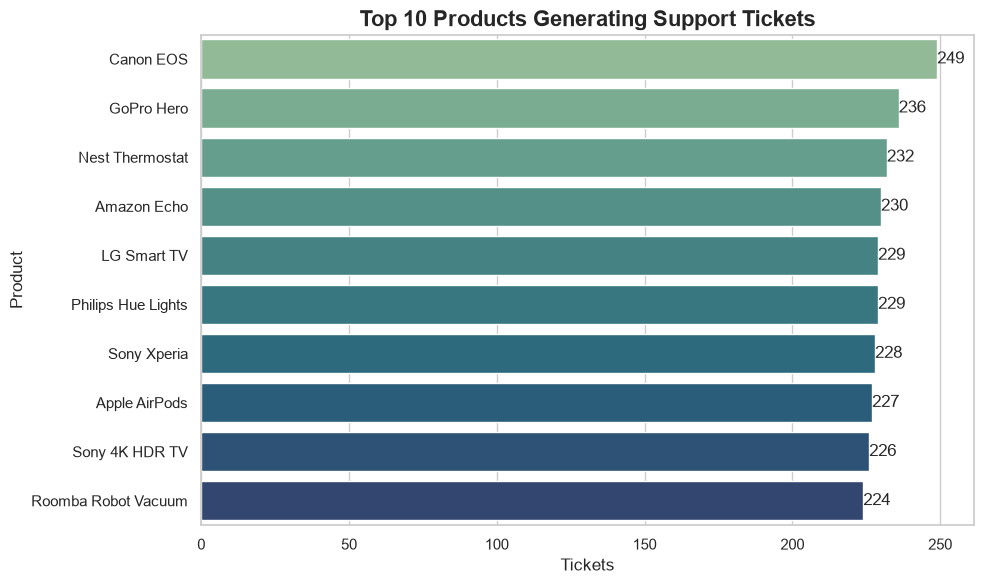

In [50]:
plt.figure(figsize=(10,6))


ax=sns.barplot(
    data=product_issues,
    x="tickets",
    y="product_name",
    palette="crest"
)


plt.title(
"Top 10 Products Generating Support Tickets",
fontsize=16,
weight="bold"
)


plt.xlabel("Tickets")
plt.ylabel("Product")


for container in ax.containers:
    ax.bar_label(container)


plt.tight_layout()

plt.show()

Customer Demographics

A. Age Distribution

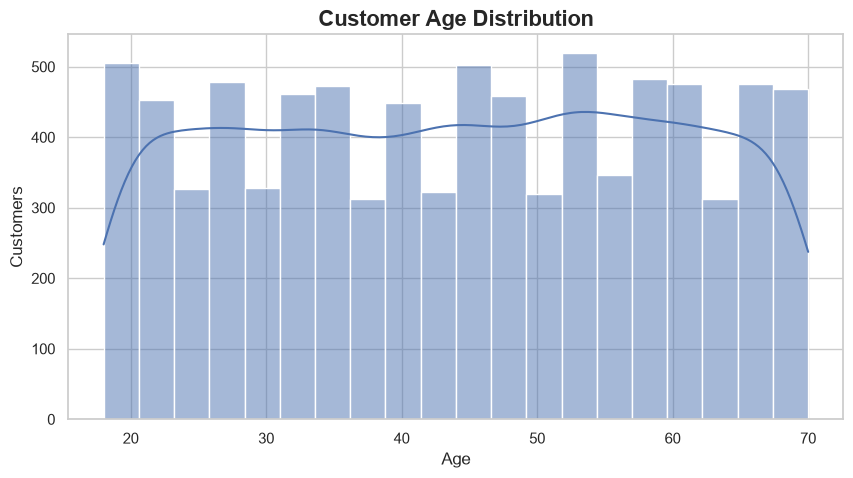

In [51]:
plt.figure(figsize=(10,5))

sns.histplot(
    dim_customers["customer_age"],
    bins=20,
    kde=True
)


plt.title(
"Customer Age Distribution",
fontsize=16,
weight="bold"
)


plt.xlabel("Age")
plt.ylabel("Customers")


plt.show()

B. Gender Analysis

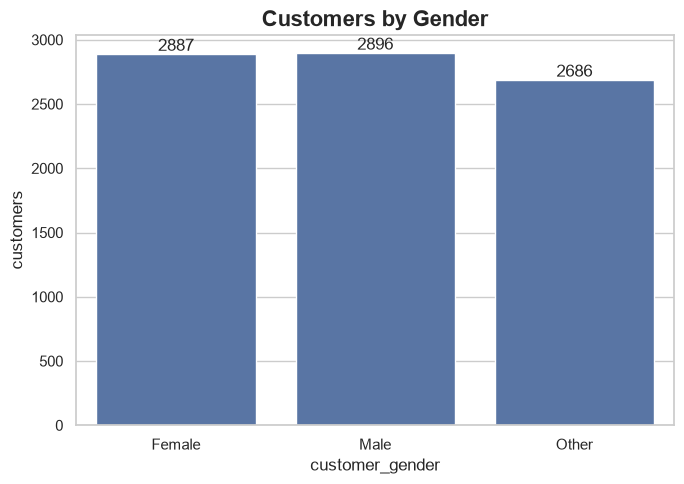

In [52]:
gender = dim_customers.groupby(
    "customer_gender"
).size().reset_index(
    name="customers"
)


plt.figure(figsize=(7,5))


ax=sns.barplot(
    data=gender,
    x="customer_gender",
    y="customers"
)


plt.title(
"Customers by Gender",
fontsize=16,
weight="bold"
)


for container in ax.containers:
    ax.bar_label(container)


plt.tight_layout()
plt.show()

Support Channel Performance

In [53]:
channels = run_query("""
SELECT

ticket_channel,

COUNT(*) AS tickets

FROM main.fact_ticket_metrics

GROUP BY ticket_channel

ORDER BY tickets DESC

""")

channels

,ticket_channel,tickets
0,Phone,2228
1,Email,2205
2,Social media,2200
3,Chat,2158


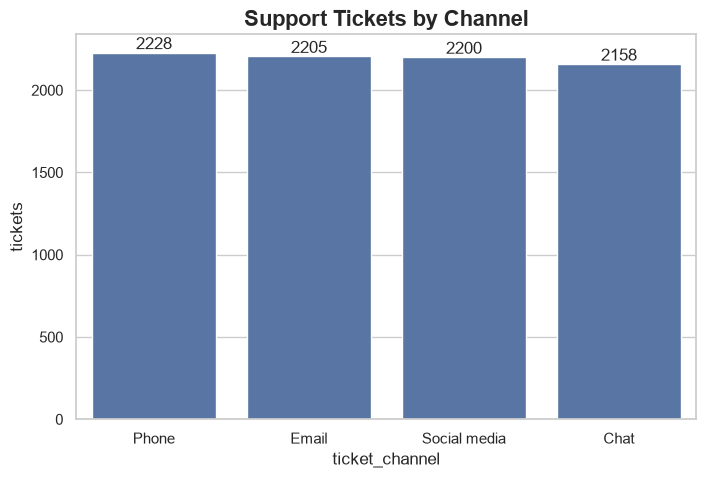

In [54]:
plt.figure(figsize=(8,5))


ax=sns.barplot(
data=channels,
x="ticket_channel",
y="tickets"
)


plt.title(
"Support Tickets by Channel",
fontsize=16,
weight="bold"
)


for container in ax.containers:
    ax.bar_label(container)


plt.show()

Resolution Performance

In [56]:
resolution = run_query("""
SELECT

    ticket_type,

    ROUND(
        AVG(
            EXTRACT(
                EPOCH 
                FROM time_to_resolution
            ) / 3600
        ),
        2
    ) AS avg_resolution_hours

FROM main.fact_ticket_metrics

GROUP BY ticket_type

ORDER BY avg_resolution_hours DESC

""")

resolution

,ticket_type,avg_resolution_hours
0,Refund request,468227.40
1,Cancellation request,468227.27
2,Product inquiry,468227.25
3,Billing inquiry,468227.20
4,Technical issue,468227.04


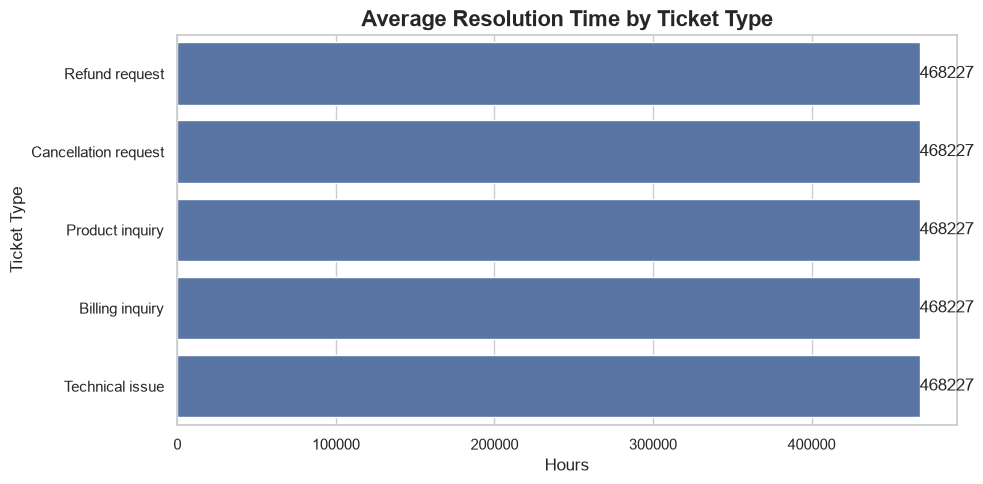

In [57]:
plt.figure(figsize=(10,5))


ax=sns.barplot(
data=resolution,
x="avg_resolution_hours",
y="ticket_type"
)


plt.title(
"Average Resolution Time by Ticket Type",
fontsize=16,
weight="bold"
)


plt.xlabel("Hours")
plt.ylabel("Ticket Type")


for container in ax.containers:
    ax.bar_label(container)


plt.tight_layout()

plt.show()

Close connection

In [4]:
conn.close()

print("Connection closed")

Connection closed


## Key Insights Summary

- The dataset contains **8,791 support tickets** from **8,469 unique customers**, with an average satisfaction score of **2.99/5**, indicating opportunities to improve customer experience.
- **Refund requests and technical issues** are the largest drivers of support demand, highlighting areas for process and product improvement.
- Ticket volume is evenly distributed across priority levels and support channels, showing that customers rely on multiple engagement points.
- Products such as **Canon EOS, GoPro Hero, and Nest Thermostat** generate the highest support volumes and should be reviewed for recurring issues.
- Improving resolution efficiency, reducing repeat issues, and addressing common customer pain points can help increase satisfaction and reduce support workload.